In [1]:
import pandas as pd 
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
os.getcwd()

'C:\\Users\\ASUS'

In [3]:
df = pd.read_csv(r'C:\Users\ASUS\Desktop\Project AQI\Cleaned_AQI.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               3655 non-null   object 
 1   Location           3655 non-null   object 
 2   PM2.5              3655 non-null   float64
 3   PM10               3655 non-null   float64
 4   NO2                3655 non-null   float64
 5   NH3                3655 non-null   float64
 6   SO2                3655 non-null   float64
 7   CO                 3655 non-null   float64
 8   O3                 3655 non-null   float64
 9   AQI                3655 non-null   int64  
 10  Severity           3655 non-null   object 
 11  Respiratory Cases  3655 non-null   int64  
dtypes: float64(7), int64(2), object(3)
memory usage: 342.8+ KB


In [5]:
df.isnull().sum()

Date                 0
Location             0
PM2.5                0
PM10                 0
NO2                  0
NH3                  0
SO2                  0
CO                   0
O3                   0
AQI                  0
Severity             0
Respiratory Cases    0
dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format = '%d-%m-%Y')

In [7]:
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['weekday'] = df['Date'].dt.day_name()

In [8]:
df.head(5)

,Date,Location,PM2.5,PM10,NO2,NH3,SO2,CO,O3,AQI,Severity,Respiratory Cases,month,year,weekday
0,2023-01-01,Bengaluru - Silk Board,45.81,82.42,24.41,20.49,5.56,0.63,29.38,85,Satisfactory,29,1,2023,Sunday
1,2023-01-01,Chennai - Alandur Bus Depot,79.77,122.73,32.64,13.60,20.39,0.96,28.80,105,Moderate,30,1,2023,Sunday
2,2023-01-01,Delhi - Punjabi Bagh,154.52,245.45,59.15,36.26,10.55,0.93,7.17,297,Poor,89,1,2023,Sunday
3,2023-01-01,Kolkata - Rabindra Bharati University,145.77,231.16,2.40,15.70,12.54,0.92,28.92,257,Poor,83,1,2023,Sunday
4,2023-01-01,Mumbai - Chhatrapati Shivaji Intl. Airport (T2),47.77,168.49,41.38,15.55,0.83,1.25,34.33,139,Moderate,49,1,2023,Sunday


In [9]:
df.columns = df.columns.str.lower()

In [10]:
df.head()

,date,location,pm2.5,pm10,no2,nh3,so2,co,o3,aqi,severity,respiratory cases,month,year,weekday
0,2023-01-01,Bengaluru - Silk Board,45.81,82.42,24.41,20.49,5.56,0.63,29.38,85,Satisfactory,29,1,2023,Sunday
1,2023-01-01,Chennai - Alandur Bus Depot,79.77,122.73,32.64,13.60,20.39,0.96,28.80,105,Moderate,30,1,2023,Sunday
2,2023-01-01,Delhi - Punjabi Bagh,154.52,245.45,59.15,36.26,10.55,0.93,7.17,297,Poor,89,1,2023,Sunday
3,2023-01-01,Kolkata - Rabindra Bharati University,145.77,231.16,2.40,15.70,12.54,0.92,28.92,257,Poor,83,1,2023,Sunday
4,2023-01-01,Mumbai - Chhatrapati Shivaji Intl. Airport (T2),47.77,168.49,41.38,15.55,0.83,1.25,34.33,139,Moderate,49,1,2023,Sunday


In [11]:
df.columns = df.columns.str.strip()
df['city'] = df['location'].str.split(' - ').str[0]


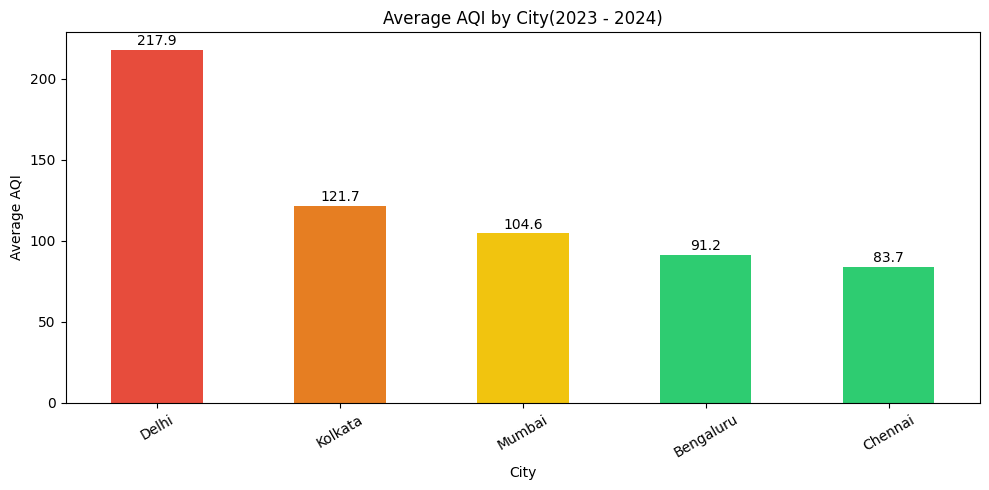

In [13]:
avg_aqi = df.groupby('city')['aqi'].mean().sort_values(ascending=False).round(1)
ax = avg_aqi.plot(kind='bar', color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#2ecc71'], figsize=(10,5))
for i, v in enumerate(avg_aqi):
    ax.text(i, v + 3, str(v), ha='center')
plt.title('Average AQI by City(2023 - 2024)')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

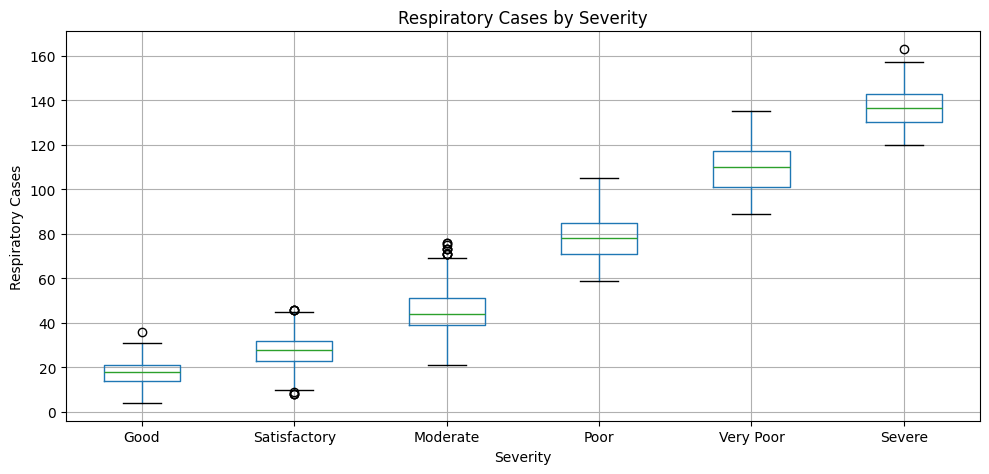

In [14]:
order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
df['severity'] = pd.Categorical(df['severity'], categories=order, ordered=True)
df.boxplot(column='respiratory cases', by='severity', figsize=(10,5))
plt.title('Respiratory Cases by Severity')
plt.suptitle('')
plt.xlabel('Severity')
plt.ylabel('Respiratory Cases')
plt.tight_layout()
plt.show()

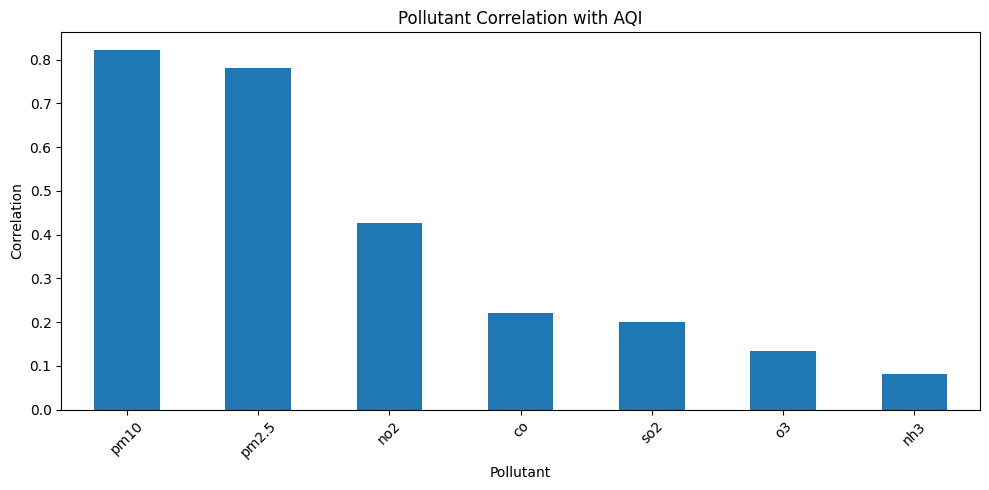

In [15]:
corr = df[['pm2.5', 'pm10', 'no2', 'nh3', 'so2', 'co', 'o3', 'aqi']].corr()['aqi'].drop('aqi').sort_values(ascending=False)
corr.plot(kind='bar', figsize=(10,5))
plt.title('Pollutant Correlation with AQI')
plt.xlabel('Pollutant')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

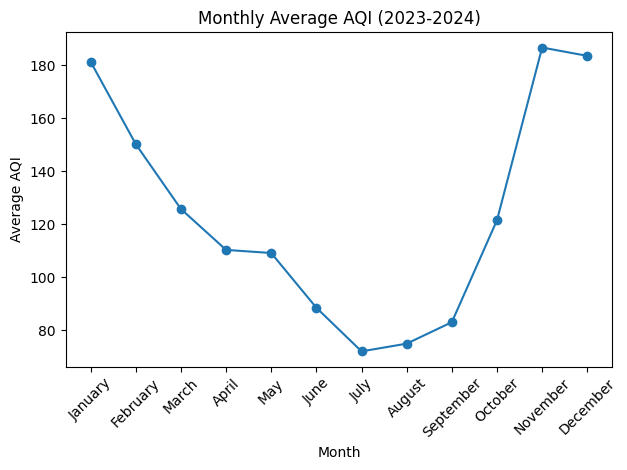

In [16]:
df['month_name'] = df['date'].dt.month_name()
monthly_aqi = df.groupby(['month', 'month_name'])['aqi'].mean().reset_index()
monthly_aqi = monthly_aqi.sort_values('month')

plt.plot(monthly_aqi['month_name'], monthly_aqi['aqi'], marker='o')
plt.title('Monthly Average AQI (2023-2024)')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_668\3971832964.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = df.groupby(['city', 'severity']).size().unstack().plot(kind='bar', stacked=True, figsize=(10,5))


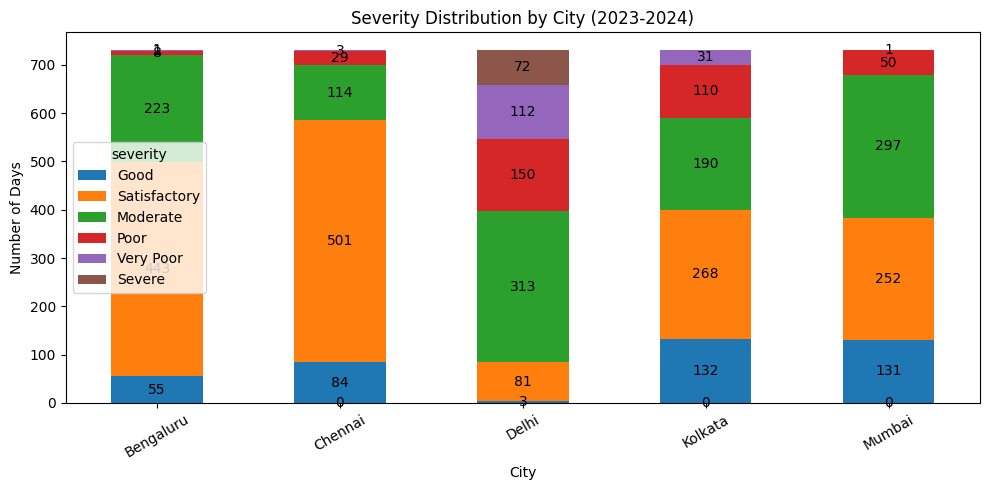

In [21]:
ax = df.groupby(['city', 'severity']).size().unstack().plot(kind='bar', stacked=True, figsize=(10,5))
for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%d')

plt.title('Severity Distribution by City (2023-2024)')
plt.xlabel('City')
plt.ylabel('Number of Days')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

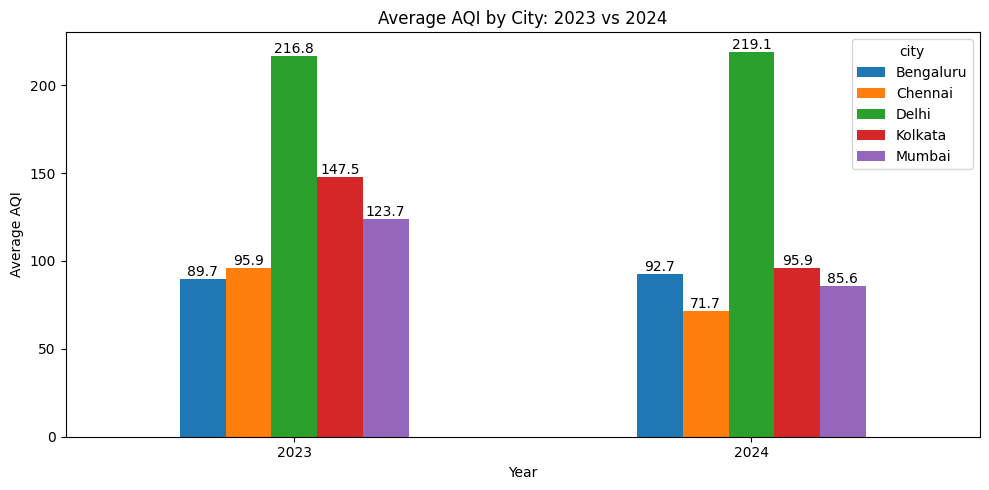

In [20]:
ax = df.groupby(['year', 'city'])['aqi'].mean().unstack().plot(kind='bar', figsize=(10,5))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Average AQI by City: 2023 vs 2024')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
features = ['pm2.5', 'pm10', 'no2', 'nh3', 'so2', 'co', 'o3']
X = df[features]
y = df['aqi']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print('R2 Score:', r2)

R2 Score: 0.8410517752596138


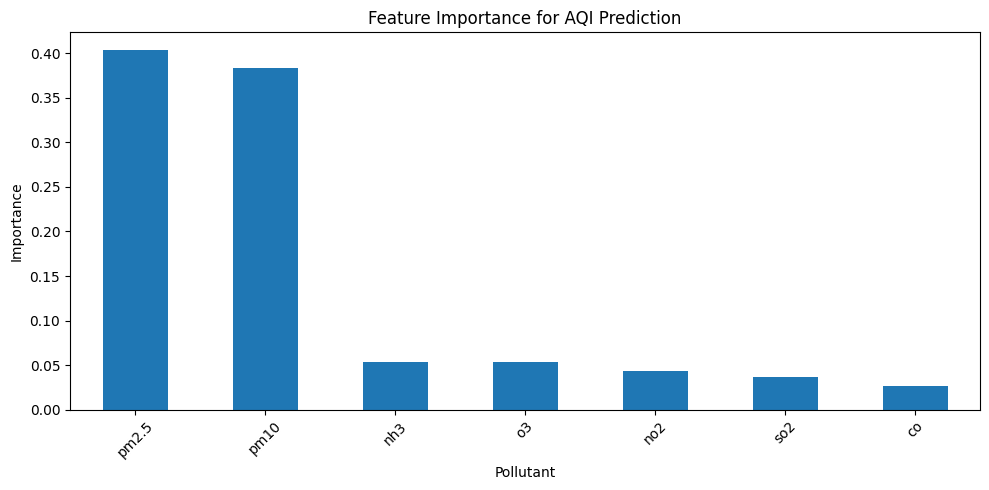

In [24]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importance.plot(kind='bar', figsize=(10,5))
plt.title('Feature Importance for AQI Prediction')
plt.xlabel('Pollutant')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)

MAE: 23.2283969369284
